# Formula 1 Podium Prediction — Phase 1: Data Preparation

**Project:** Predicting F1 Race Podium Finishes using Artificial Neural Networks

**Dataset:** Kaggle F1 World Championship (1950-2024)

**Phase 1:** Loading and Understanding the Dataset


***_Problem Description_***

I chose to predict which drivers will finish on the podium (top 3) in Formula 1 races using historical Grand Prix data. This involves analyzing various race, driver, constructor, and qualifying features to build an effective predictive model. My datasets are sourced from the Formula 1 World Championship (1950-2020) on Kaggle.
https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020?resource=download

***_Inputs and Outputs_***

The input consists of numeric and categorical race features that are collected from various stages of a typical Formula 1 race weekend. Some examples of these features are grid position, qualifying result, historical driver and constructor podium appearances, recent form, e.t.c.

The output is a binary label (0 or 1), predicting whether the driver will finish on the podium (yes/no).

***_Problem Type_***

This is a binary classification problem. The model predicts whetehr each driver will finish the race on the podium or not.

***_Features Used_***

- Grid position
- Qualifying position
- Driver career podium appearances
- Recent driver form
- Constructor season form
- Constructor podium history
- Driver and constructor history at specific tracks/circuits
- Year and round number (for chronology)

***_Evaluation Metrics_***

Accuracy and ROC-AUC are the primary evaluation metrics for this project.

## 1: Load the Dataset

### 1.1: Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.width',None)

print("Libraries imported successfully.")

Libraries imported successfully.


### 1.2: Load All CSV Files

The Kaggle F1 dataset contains multiple CSV files. We'll load the most relevant ones for podium prediction.

In [41]:
DATA_PATH = 'datasets/'

print("Loading Formula 1 datasets...")

df_results = pd.read_csv(DATA_PATH + 'results.csv')
df_races = pd.read_csv(DATA_PATH + 'races.csv')
df_drivers = pd.read_csv(DATA_PATH + 'drivers.csv')
df_constructors = pd.read_csv(DATA_PATH + 'constructors.csv')
df_qualifying = pd.read_csv(DATA_PATH + 'qualifying.csv')
df_circuits = pd.read_csv(DATA_PATH + 'circuits.csv')

print("All datasets loaded successfuly!")

Loading Formula 1 datasets...
All datasets loaded successfuly!


### 1.3: Inspect Dataset Structure

#### Results Table (Core table with race outcomes)

In [42]:
print("RESULTS TABLE - Core race outcome data")
print(f"\nShape: {df_results.shape}")
print("\nColumns:")
print(df_results.dtypes)
print("\nFirst 5 rows:")
print(df_results.head())
print("\nBasic statistics:")
print(df_results.describe())

RESULTS TABLE - Core race outcome data

Shape: (26759, 18)

Columns:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

First 5 rows:
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5

#### Races Table (Race metadata)

In [43]:
print("RACES TABLE - Race event information")
print(f"\nShape: {df_races.shape}")
print("\nColumns:")
print(df_races.dtypes)
print("\nFirst 5 rows:")
print(df_races.head())
print("\nBasic statistics:")
print(df_races.describe())

RACES TABLE - Race event information

Shape: (1125, 18)

Columns:
raceId          int64
year            int64
round           int64
circuitId       int64
name           object
date           object
time           object
url            object
fp1_date       object
fp1_time       object
fp2_date       object
fp2_time       object
fp3_date       object
fp3_time       object
quali_date     object
quali_time     object
sprint_date    object
sprint_time    object
dtype: object

First 5 rows:
   raceId  year  round  circuitId                   name        date  \
0       1  2009      1          1  Australian Grand Prix  2009-03-29   
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05   
2       3  2009      3         17     Chinese Grand Prix  2009-04-19   
3       4  2009      4          3     Bahrain Grand Prix  2009-04-26   
4       5  2009      5          4     Spanish Grand Prix  2009-05-10   

       time                                                url fp1_date  \
0

#### Drivers Table

In [44]:
print("DRIVERS TABLE - Driver information")
print(f"\nShape: {df_drivers.shape}")
print("\nColumns:")
print(df_drivers.dtypes)
print("\nFirst 5 rows:")
print(df_drivers.head())
print("\nBasic statistics:")
print(df_drivers.describe())

DRIVERS TABLE - Driver information

Shape: (861, 9)

Columns:
driverId        int64
driverRef      object
number         object
code           object
forename       object
surname        object
dob            object
nationality    object
url            object
dtype: object

First 5 rows:
   driverId   driverRef number code  forename     surname         dob  \
0         1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07   
1         2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10   
2         3     rosberg      6  ROS      Nico     Rosberg  1985-06-27   
3         4      alonso     14  ALO  Fernando      Alonso  1981-07-29   
4         5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19   

  nationality                                             url  
0     British     http://en.wikipedia.org/wiki/Lewis_Hamilton  
1      German      http://en.wikipedia.org/wiki/Nick_Heidfeld  
2      German       http://en.wikipedia.org/wiki/Nico_Rosberg  
3     Spanish   

#### Constructors Table

In [45]:
print("CONSTRUCTORS TABLE - Team information")
print(f"\nShape: {df_constructors.shape}")
print("\nColumns:")
print(df_constructors.dtypes)
print("\nFirst 5 rows:")
print(df_constructors.head())
print("\nBasic statistics:")
print(df_constructors.describe())

CONSTRUCTORS TABLE - Team information

Shape: (212, 5)

Columns:
constructorId      int64
constructorRef    object
name              object
nationality       object
url               object
dtype: object

First 5 rows:
   constructorId constructorRef        name nationality  \
0              1        mclaren     McLaren     British   
1              2     bmw_sauber  BMW Sauber      German   
2              3       williams    Williams     British   
3              4        renault     Renault      French   
4              5     toro_rosso  Toro Rosso     Italian   

                                                 url  
0               http://en.wikipedia.org/wiki/McLaren  
1            http://en.wikipedia.org/wiki/BMW_Sauber  
2  http://en.wikipedia.org/wiki/Williams_Grand_Pr...  
3  http://en.wikipedia.org/wiki/Renault_in_Formul...  
4   http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso  

Basic statistics:
       constructorId
count     212.000000
mean      107.547170
std        61.

#### Qualifying Table

In [46]:
print("QUALIFYING TABLE - Qualifying session results")
print(f"\nShape: {df_qualifying.shape}")
print("\nColumns:")
print(df_qualifying.dtypes)
print("\nFirst 5 rows:")
print(df_qualifying.head())
print("\nBasic statistics:")
print(df_qualifying.describe())

QUALIFYING TABLE - Qualifying session results

Shape: (10494, 9)

Columns:
qualifyId         int64
raceId            int64
driverId          int64
constructorId     int64
number            int64
position          int64
q1               object
q2               object
q3               object
dtype: object

First 5 rows:
   qualifyId  raceId  driverId  constructorId  number  position        q1  \
0          1      18         1              1      22         1  1:26.572   
1          2      18         9              2       4         2  1:26.103   
2          3      18         5              1      23         3  1:25.664   
3          4      18        13              6       2         4  1:25.994   
4          5      18         2              2       3         5  1:25.960   

         q2        q3  
0  1:25.187  1:26.714  
1  1:25.315  1:26.869  
2  1:25.452  1:27.079  
3  1:25.691  1:27.178  
4  1:25.518  1:27.236  

Basic statistics:
          qualifyId        raceId      driverId  const

#### Circuits Table

In [47]:
print("CIRCUITS TABLE - Circuit/track information")
print(f"\nShape: {df_circuits.shape}")
print("\nColumns:")
print(df_circuits.dtypes)
print("\nFirst 5 rows:")
print(df_circuits.head())
print("\nBasic statistics:")
print(df_circuits.describe())

CIRCUITS TABLE - Circuit/track information

Shape: (77, 9)

Columns:
circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object

First 5 rows:
   circuitId   circuitRef                            name      location  \
0          1  albert_park  Albert Park Grand Prix Circuit     Melbourne   
1          2       sepang    Sepang International Circuit  Kuala Lumpur   
2          3      bahrain   Bahrain International Circuit        Sakhir   
3          4    catalunya  Circuit de Barcelona-Catalunya      Montmeló   
4          5     istanbul                   Istanbul Park      Istanbul   

     country       lat        lng  alt  \
0  Australia -37.84970  144.96800   10   
1   Malaysia   2.76083  101.73800   18   
2    Bahrain  26.03250   50.51060    7   
3      Spain  41.57000    2.26111  109   
4     Turkey  40.95170   29.40500  130   



#### Key Relationships
1. results → races (via raceId)
2. results → drivers (via driverId)
3. results → constructors (via constructorId)
4. results → status (via statusId)
5. races → circuits (via circuitId)
6. qualifying → races (via raceId)
7. qualifying → drivers (via driverId)
8. qualifying → constructors (via constructorId)
9. driver_standings → races (via raceId)
10. driver_standings → drivers (via driverId)
11. constructor_standings → races (via raceId)
12. constructor_standings → constructors (via constructorId)

## 2: Data Exploration

### 2.1 Podium Distribution Over Time

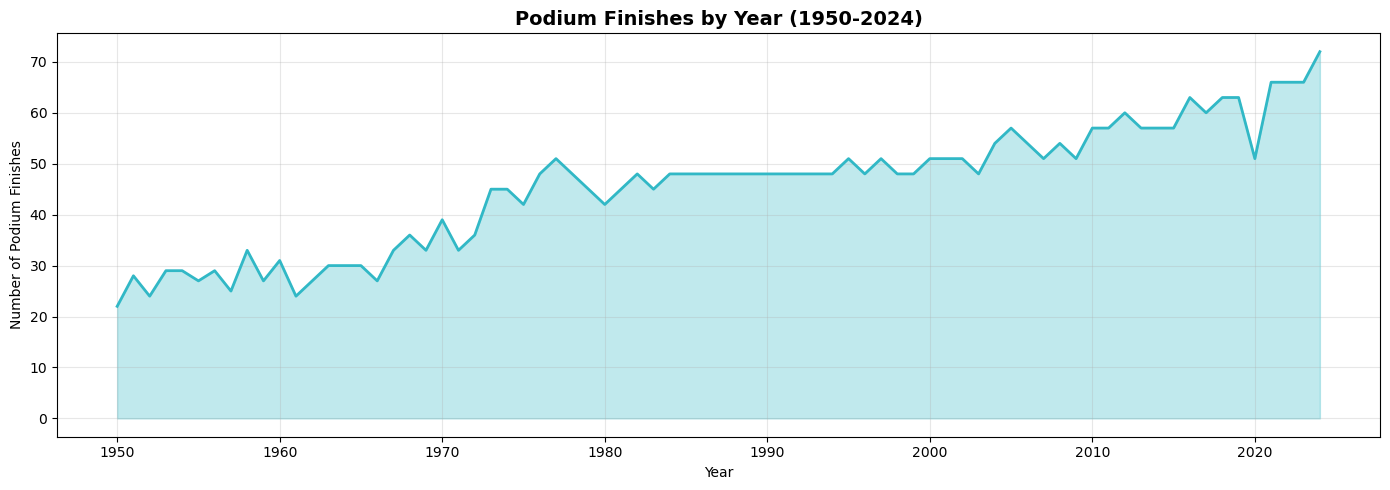

In [48]:
# Podium finishes by year
df_podium_yearly = df_results.merge(df_races[['raceId','year']], on='raceId')
df_podium_yearly['is_podium'] = (df_podium_yearly['positionOrder'] <= 3).astype(int)

yearly_podiums = df_podium_yearly.groupby('year')['is_podium'].sum()

plt.figure(figsize=(14,5))
plt.plot(yearly_podiums.index, yearly_podiums.values, linewidth=2, color='#31b8c6')
plt.fill_between(yearly_podiums.index, yearly_podiums.values, alpha=0.3, color='#31b8c6')
plt.title('Podium Finishes by Year (1950-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Podium Finishes')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Constructor Dominance

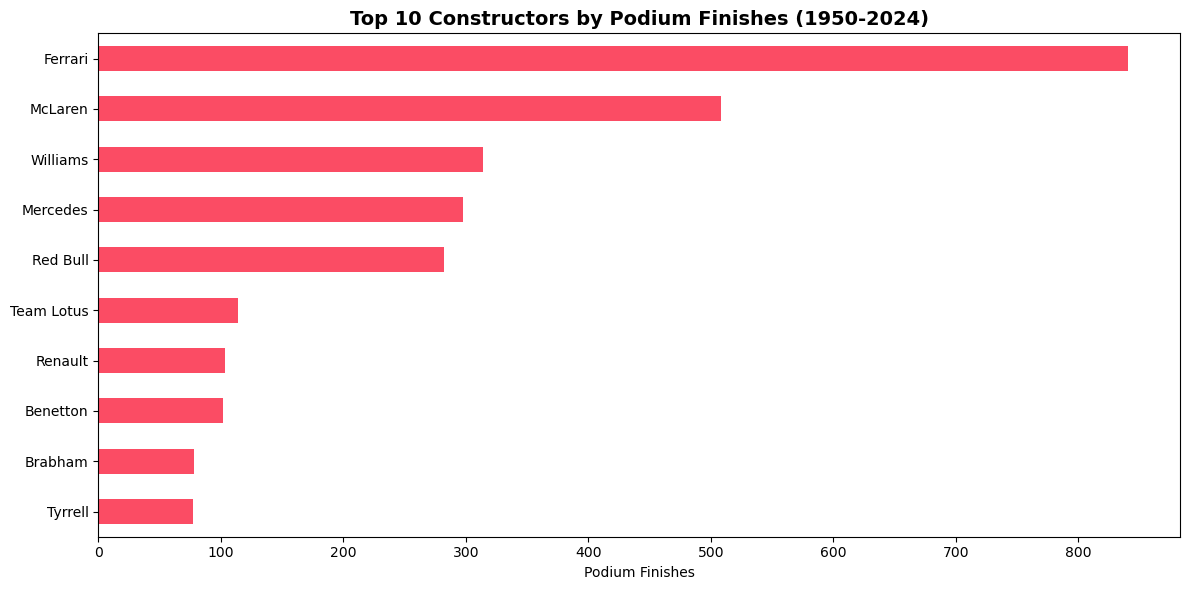

In [49]:
# Top 10 constructors by podium count
constructor_podiums = df_results[df_results['positionOrder'] <= 3].merge(
    df_constructors[['constructorId','name']], on='constructorId'
).groupby('name').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
constructor_podiums.plot(kind='barh', color='#fb4c64')
plt.title('Top 10 Constructors by Podium Finishes (1950-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Podium Finishes')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 2.3 Grid Position vs Podium Probability

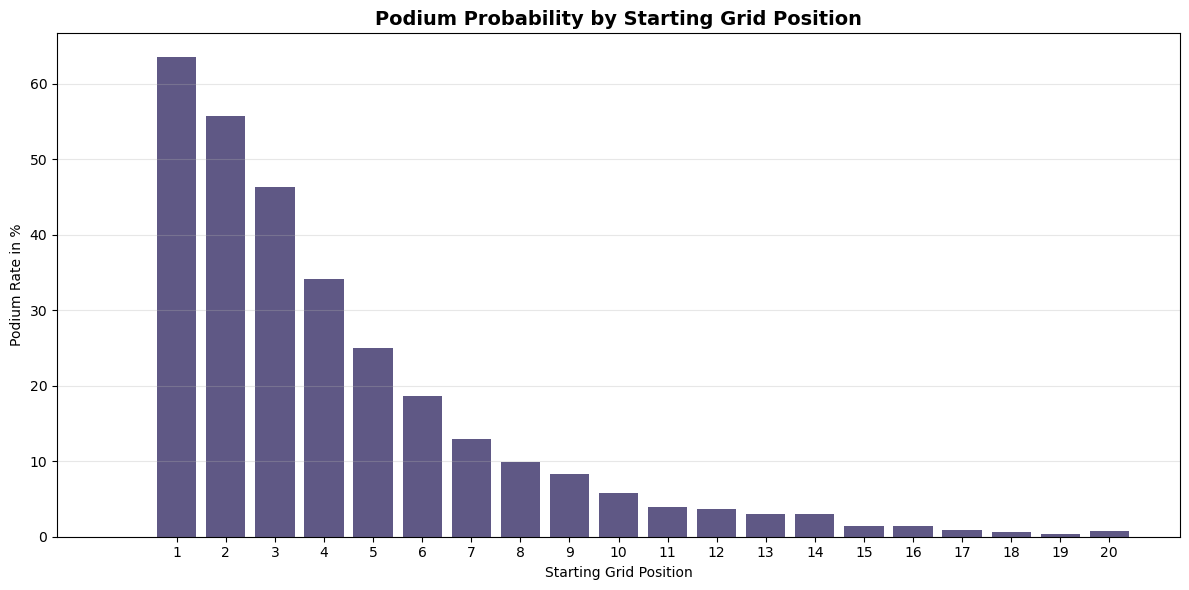

In [50]:
# Calculate podium rate by starting grid position
grid_analysis = df_results[df_results['grid'] <= 20].copy()
grid_analysis['is_podium'] = (grid_analysis['positionOrder'] <= 3).astype(int)
podium_rate_by_grid = grid_analysis.groupby('grid')['is_podium'].mean() * 100

plt.figure(figsize=(12, 6))
plt.bar(podium_rate_by_grid.index, podium_rate_by_grid.values, color='#372e67', alpha=0.8)
plt.title('Podium Probability by Starting Grid Position', fontsize=14, fontweight='bold')
plt.xlabel('Starting Grid Position')
plt.ylabel('Podium Rate in %')
plt.xticks(range(1,21))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


*Possibly include section 2.7?*

## 3: Data Cleaning & Integration

### 3.1: Merge Core Tables

In [51]:
# Start with results as the base of our dataframe
df_merged = df_results.copy()

# Add race information
df_merged = df_merged.merge(
    df_races[['raceId','year','round','circuitId','date']],
    on='raceId',
    how='left'
)

# Add driver information
df_merged = df_merged.merge(
    df_drivers[['driverId','driverRef','code','surname','dob','nationality']],
    on='driverId',
    how='left'
)

# Add constructor information
df_merged = df_merged.merge(
    df_constructors[['constructorId','constructorRef','name','nationality']],
    on='constructorId',
    how='left',
    suffixes=('_driver','_constructor')
)

# Add circuit information
df_merged = df_merged.merge(
    df_circuits[['circuitId','circuitRef','name','location','country']],
    on='circuitId',
    how='left',
    suffixes=('','_circuitId')
)

# Add qualifying data
df_merged = df_merged.merge(
    df_qualifying[['raceId','driverId','position','q1','q2','q3']],
    on=['raceId','driverId'],
    how='left',
    suffixes=('','_quali')
)

print(f"Merged dataset rows: {df_merged.shape[0]}")
print(f"Merged dataset columns: {df_merged.shape[1]}")

Merged dataset rows: 26759
Merged dataset columns: 38


### 3.2: Create Target Variable

In [52]:
# Binary: Is this driver on the podium?
df_merged['is_podium'] = (df_merged['positionOrder'] <= 3).astype(int)

print("Target variable created.")
print(f"Podium: {df_merged['is_podium'].sum():,} ({df_merged['is_podium'].mean()*100:.1f}%)")
print(f"No Podium: {(df_merged['is_podium']==0).sum():,} ({(df_merged['is_podium']==0).mean()*100:.1f}%)")

Target variable created.
Podium: 3,397 (12.7%)
No Podium: 23,362 (87.3%)


### 3.3: Handle Missing Values

In [53]:
# Check missing values in key columns
key_columns = ['grid','position_quali','q1','q2','q3','laps','milliseconds',
               'fastestLap','fastestLapTime','fastestLapSpeed']

missing_summary = df_merged[key_columns].isna().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df_merged) * 100).round(1)

print("Missing values in Key Columns:")
for col in missing_summary.index:
    if missing_summary[col] > 0:
        print(f"{col:20s}: {missing_summary[col]:6,} ({missing_pct[col]:5.1f}%)")

Missing values in Key Columns:
q3                  : 16,311 ( 61.0%)
q2                  : 16,287 ( 60.9%)
position_quali      : 16,265 ( 60.8%)
q1                  : 16,265 ( 60.8%)


In [54]:
# Fill grid position with qualifying position when missing
df_merged['grid'] = df_merged['grid'].fillna(df_merged['position_quali'])

# Drop rows with missing grid
df_clean = df_merged[df_merged['grid'].notna()].copy()

print(f"Dataset after cleaning: {df_clean.shape[0]:,} records")
print(f"Records removed: {df_merged.shape[0] - df_clean.shape[0]:,}")

Dataset after cleaning: 26,759 records
Records removed: 0


In our case, it seems like there aren't any missing 'grid' (starting position) values. Which is a good thing.

### 3.4: Filter to a Specific time Period

In [55]:
# Focus on the modern era (2000-2024) for consistent records and data quality
df_clean = df_clean[df_clean['year'] >= 2000].copy()

print(f"Dataset filtered to 2000-2024: {df_clean.shape[0]:,} records")
print(f"Years covered: {df_clean['year'].min()} - {df_clean['year'].max()}")
print(f"Races: {df_clean['raceId'].nunique():,}")
print(f"Drivers: {df_clean['driverId'].nunique():,}")
print(f"Constructors: {df_clean['constructorId'].nunique():,}")

Dataset filtered to 2000-2024: 10,079 records
Years covered: 2000 - 2024
Races: 479
Drivers: 126
Constructors: 38


### 3.5: Create Basic Feature Set

In [56]:
# Select initial feature columns for modeling
feature_columns = [
    # Identifiers
    'raceId','driverId','constructorId','circuitId',
    
    # Starting Position
    'grid',
    
    # Qualifying
    'position_quali',
    
    # Race Context
    'year','round','positionOrder',
    
    # Target
    'is_podium'
]

df_final = df_clean[feature_columns].copy()

# Check data types
print("Feature Data Types:")
print(df_final.dtypes)

print(f"\nFinal dataset ready: {df_final.shape[0]} records")

Feature Data Types:
raceId              int64
driverId            int64
constructorId       int64
circuitId           int64
grid                int64
position_quali    float64
year                int64
round               int64
positionOrder       int64
is_podium           int32
dtype: object

Final dataset ready: 10079 records


### 3.6 Save Cleaned Dataset

In [57]:
df_final.to_csv('f1_data_clean.csv', index=False)
print("Cleaned dataset saved as 'f1_data_clean.csv'")

Cleaned dataset saved as 'f1_data_clean.csv'


## 4: Create Advanced Features

In [58]:
# Load cleaned data
df = pd.read_csv('f1_data_clean.csv')

# Sort by date for time-based features
df = df.sort_values(['year','round','grid']).reset_index(drop=True)

### 4.1: Driver Historical Performance

In [59]:
# Career podiums before this race
df['driver_career_podiums'] = (
    df.groupby('driverId')['is_podium'].cumsum().shift(1).fillna(0)
)

# Races compelted before this race
df['driver_race_count'] = df.groupby('driverId').cumcount()

# Driver podium rate
df['driver_podium_rate'] = np.where(
    df['driver_race_count'] > 0,
    df['driver_career_podiums'] / df['driver_race_count'],
    0
)

### 4.2: Recent Form

Over the last 5 races. 

In [60]:
# Average finish position in the last 5 races
df['driver_recent_avg_position'] = (
    df.groupby('driverId')['positionOrder']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
    .fillna(15)
)

# Podiums in the last 5 races
df['driver_recent_podiums'] = (
    df.groupby('driverId')['is_podium']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
    .fillna(0)
)

### 4.3: Constructor Performance

In [61]:
# Constructor podiums this season (up until this race)
df['constructor_season_podiums'] = (
    df.groupby(['year','constructorId'])['is_podium'].cumsum().shift(1).fillna(0)
)

# Constructor podium rate (up until this race)
df['constructor_career_podiums'] = (
    df.groupby('constructorId')['is_podium'].cumsum().shift(1).fillna(0)
)

df['constructor_race_count'] = df.groupby('constructorId').cumcount()

df['constructor_podium_rate'] = np.where(
    df['constructor_race_count'] > 0,
    df['constructor_career_podiums'] / df['constructor_race_count'],
    0
)

### 4.4: Circuit-Specific Features

In [62]:
# Driver's history at this circuit
df['driver_circuit_podiums'] = (
    df.groupby(['driverId','circuitId'])['is_podium'].cumsum().shift(1).fillna(0)
)

df['driver_circuit_races'] = (
    df.groupby(['driverId','circuitId']).cumcount()
)

# Constructor performance at this circuit
df['constructor_circuit_podiums'] = (
    df.groupby(['constructorId','circuitId'])['is_podium']
    .cumsum().shift(1).fillna(0)
)

### 4.5: Championship Context

In [63]:
# Points before this race (season standings proxy)
# Note: Actual points not in basic dataset, using podium count in place of points
df['driver_season_podiums'] = (
    df.groupby(['year','driverId'])['is_podium']
    .cumsum().shift(1).fillna(0)
)

### 4.6 Save Feature-Engineered Dataset

In [64]:
df.to_csv('f1_data_featured.csv', index=False)

print("Feature engineering complete.")
print("\nDataset shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Feature engineering complete.

Dataset shape:
Rows: 10079
Columns: 23


## 5: Data Preprocessing

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('f1_data_featured.csv')

### 5.1: Select Features & Target

In [66]:
# Feature list
features = [
    'grid',
    'position_quali',
    'driver_career_podiums',
    'driver_race_count',
    'driver_podium_rate',
    'driver_recent_avg_position',
    'driver_recent_podiums',
    'constructor_season_podiums',
    'constructor_podium_rate',
    'driver_circuit_podiums',
    'driver_circuit_races',
    'constructor_circuit_podiums',
    'driver_season_podiums',
    'year'
]

target = 'is_podium'

# Create X and y
X = df[features].fillna(0)
y = df[target]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print("\nTarget distribution:")
print(f"    Podium:     {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"    No Podium:  {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")

Features: 14
Samples: 10079

Target distribution:
    Podium:     1,437 (14.3%)
    No Podium:  8,642 (85.7%)


### 5.2 Split the Data (Temporal Split)

Formula 1 race data is time-series based and the goal is to predict future races using past data. Stratified splitting would mix data across seasons and years, allowing the model to see information from races that occur after those it's supposed to predict. This can lead to data leakage and unrealistically high performance estimates.

Instead of a stratified split, we use a temporal split. This allows us to train the model on older races, validate on a 'middle' period, and test on the most recent races. This will give the model the ability to more accurately predict race outcomes without it having any "premonitions".

In [67]:
# Ensure that the dataset is sorted
df_sorted = df.sort_values(['year','round']).reset_index(drop=True)
X_sorted = df_sorted[features].fillna(0)
y_sorted = df_sorted[target]

# Split: 70% training, 15% validation, 15% testing (in chronological order)
n = len(X_sorted)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X_sorted[:train_end]
y_train = y_sorted[:train_end]

X_val = X_sorted[train_end:val_end]
y_val = y_sorted[train_end:val_end]

X_test = X_sorted[val_end:]
y_test = y_sorted[val_end:]

print(f"Train: {len(X_train):,} samples ({len(X_train)/n*100:.1f}%)")
print(f"Val:   {len(X_val):,} samples ({len(X_val)/n*100:.1f}%)")
print(f"Test:  {len(X_test):,} samples ({len(X_test)/n*100:.1f}%)")

print(f"\nTrain years: {df_sorted.iloc[:train_end]['year'].min()}-{df_sorted.iloc[:train_end]['year'].max()}")
print(f"Val years:   {df_sorted.iloc[train_end:val_end]['year'].min()}-{df_sorted.iloc[train_end:val_end]['year'].max()}")
print(f"Test years:  {df_sorted.iloc[val_end:]['year'].min()}-{df_sorted.iloc[val_end:]['year'].max()}")

Train: 7,055 samples (70.0%)
Val:   1,512 samples (15.0%)
Test:  1,512 samples (15.0%)

Train years: 2000-2017
Val years:   2017-2021
Test years:  2021-2024


### 5.3 Feature Scaling

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")

Scaling complete.
Train mean: 0.000000, std: 1.000000


### 5.4 Class Distribution Check

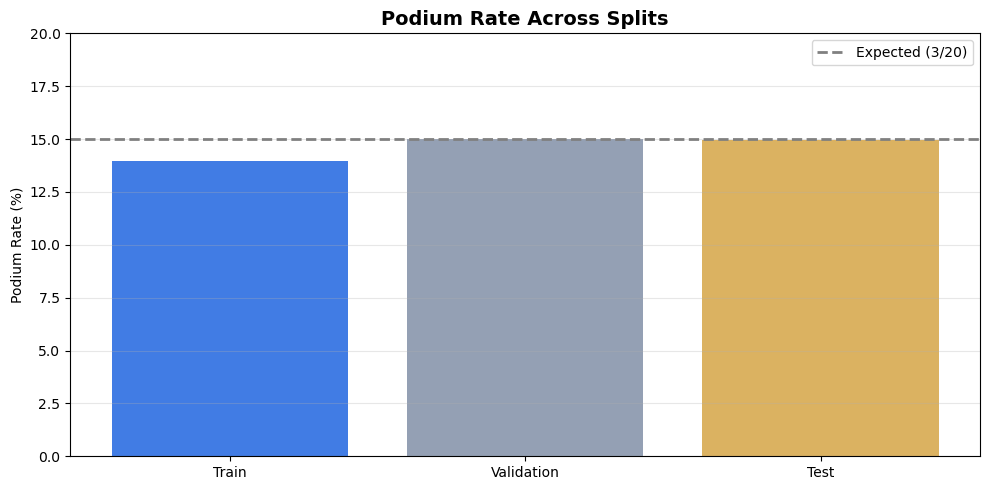

Train: 13.95%
Validation: 15.01%
Test: 14.95%


In [69]:
splits = ['Train', 'Validation', 'Test']
podium_rates = [
    y_train.mean() * 100,
    y_val.mean() * 100,
    y_test.mean() * 100
]

plt.figure(figsize=(10, 5))
plt.bar(splits, podium_rates, color=['#115bde', '#7a88a1', '#d29f39'], alpha=0.8)
plt.axhline(y=15, color='gray', linestyle='--', linewidth=2, label='Expected (3/20)')
plt.title('Podium Rate Across Splits', fontsize=14, fontweight='bold')
plt.ylabel('Podium Rate (%)')
plt.ylim(0, 20)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for split, rate in zip(splits, podium_rates):
    print(f"{split}: {rate:.2f}%")


### 5.5 Feature Correlation Heatmap

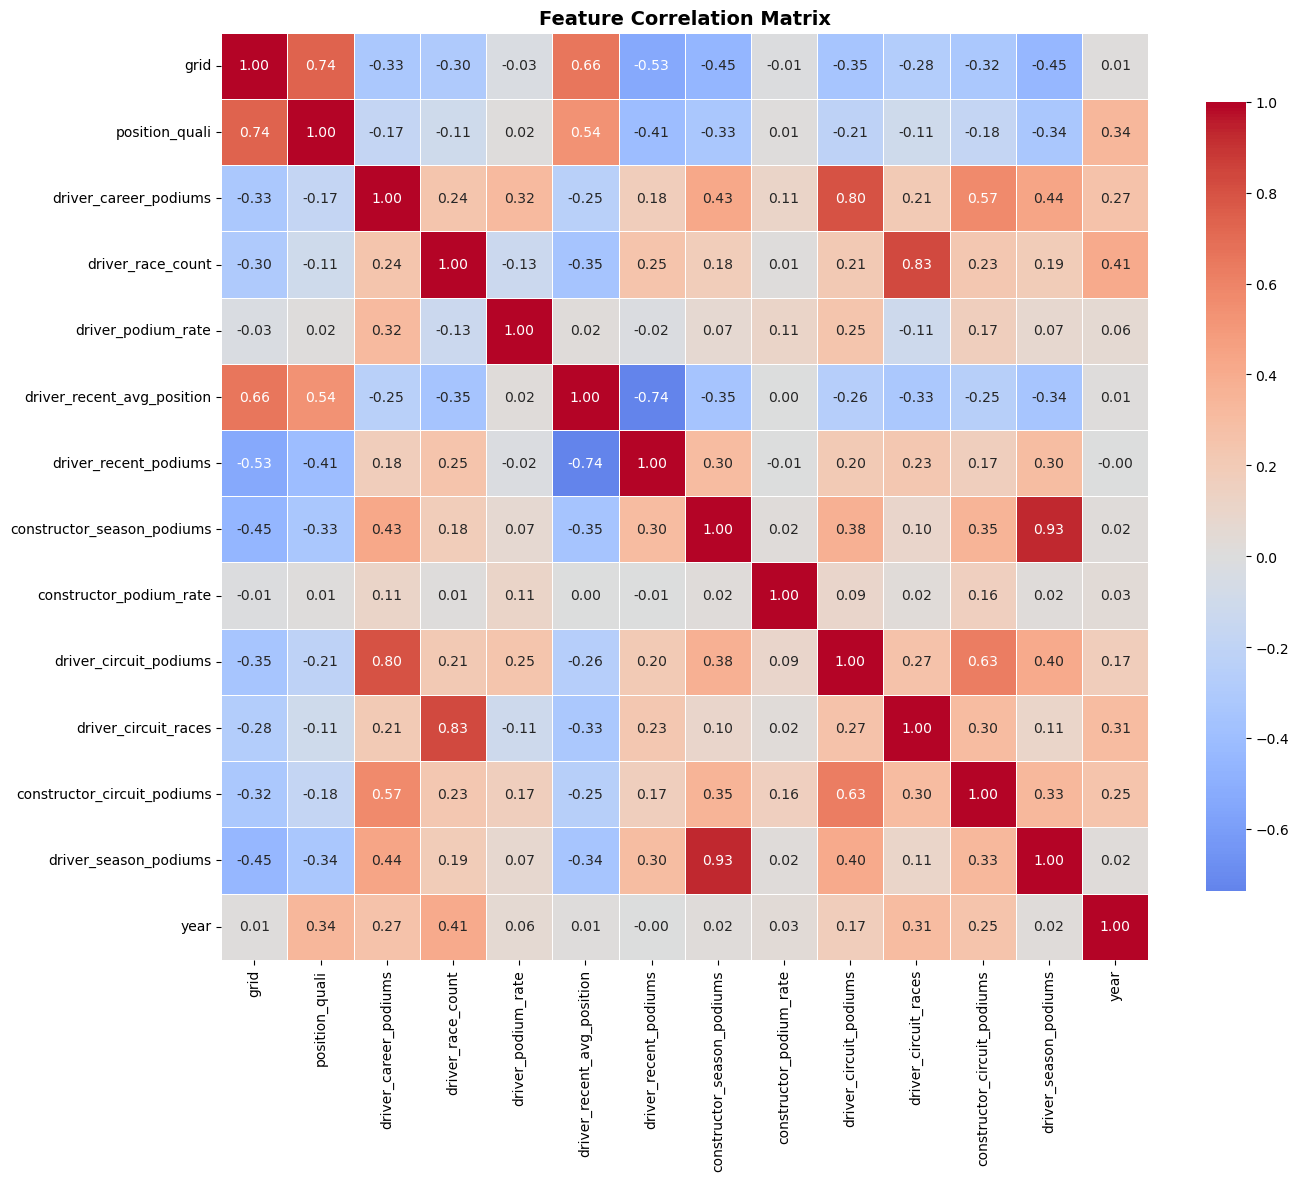

In [70]:
corr_matrix = X_train.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.6 Save Preprocessed Data

In [71]:
import joblib

np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_val_scaled.npy', X_val_scaled)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('y_train.npy', y_train.values)
np.save('y_val.npy', y_val.values)
np.save('y_test.npy', y_test.values)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## 6: Build the Neural Network

In [72]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Load preprocessed data
import numpy as np

X_train = np.load('X_train_scaled.npy')
X_val = np.load('X_val_scaled.npy')
X_test = np.load('X_test_scaled.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

### 6.1: Define the Model

In [73]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1])),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

In [74]:
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 32)                480       
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1,025
Trainable params: 1,025
Non-trainable params: 0
_________________________________________________________________


### 6.2: Train the Model

In [75]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint('best_model.keras', monitor='val_auc', save_best_only=True, mode='max')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100
221/221 [==============================] - 1s 2ms/step - loss: 0.4619 - accuracy: 0.7785 - auc: 0.7053 - val_loss: 0.2609 - val_accuracy: 0.8598 - val_auc: 0.9111
Epoch 2/100
221/221 [==============================] - 0s 2ms/step - loss: 0.2650 - accuracy: 0.8845 - auc: 0.8923 - val_loss: 0.2449 - val_accuracy: 0.8757 - val_auc: 0.9191
Epoch 3/100
221/221 [==============================] - 0s 1ms/step - loss: 0.2579 - accuracy: 0.8883 - auc: 0.8985 - val_loss: 0.2427 - val_accuracy: 0.8770 - val_auc: 0.9222
Epoch 4/100
221/221 [==============================] - 0s 1ms/step - loss: 0.2545 - accuracy: 0.8879 - auc: 0.9022 - val_loss: 0.2330 - val_accuracy: 0.8968 - val_auc: 0.9250
Epoch 5/100
221/221 [==============================] - 0s 1ms/step - loss: 0.2482 - accuracy: 0.8880 - auc: 0.9078 - val_loss: 0.2330 - val_accuracy: 0.8942 - val_auc: 0.9248
Epoch 6/100
221/221 [==============================] - 0s 1ms/step - loss: 0.2505 - accuracy: 0.8893 - auc: 0.9054 - val_loss

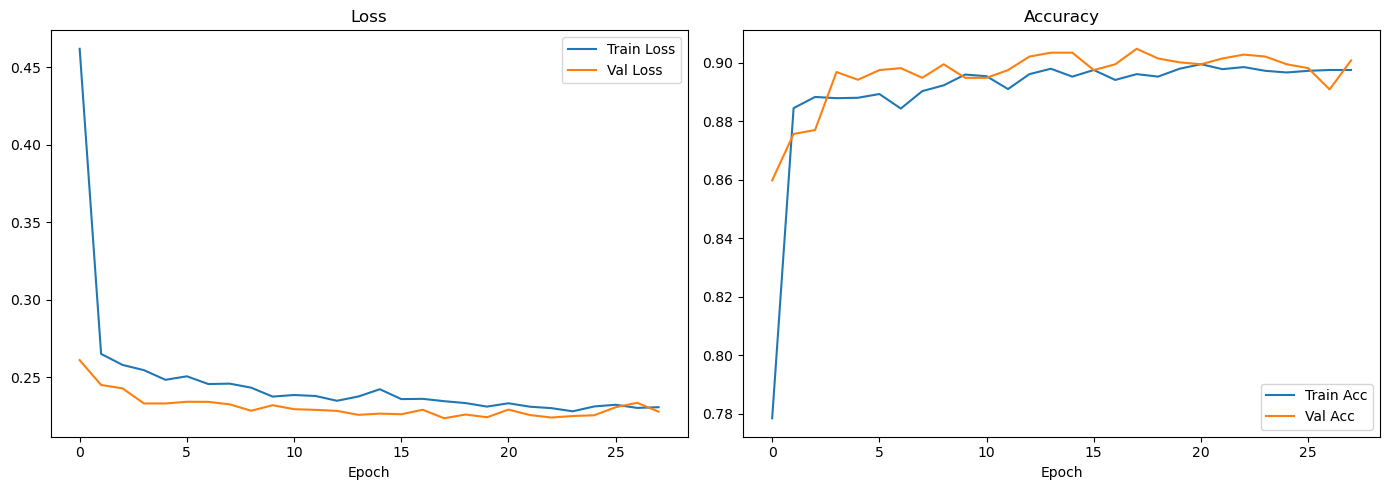

In [76]:
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(), plt.title('Loss'), plt.xlabel('Epoch')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(), plt.title('Accuracy'), plt.xlabel('Epoch')
plt.tight_layout()
plt.show()


## 7: Evaluation

### 7.1: Evaluate on the Test Set

In [77]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load best weights
model.load_weights('best_model.keras')

# Predict
y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Metrics
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba))

48/48 [==============================] - 0s 530us/step
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1286
           1       0.76      0.48      0.59       226

    accuracy                           0.90      1512
   macro avg       0.84      0.73      0.77      1512
weighted avg       0.89      0.90      0.89      1512

ROC-AUC: 0.9307174610165293


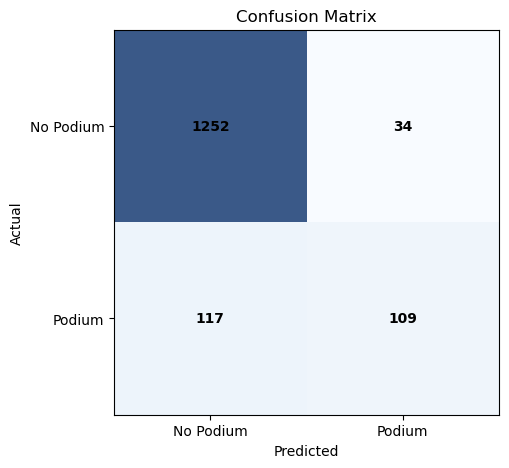

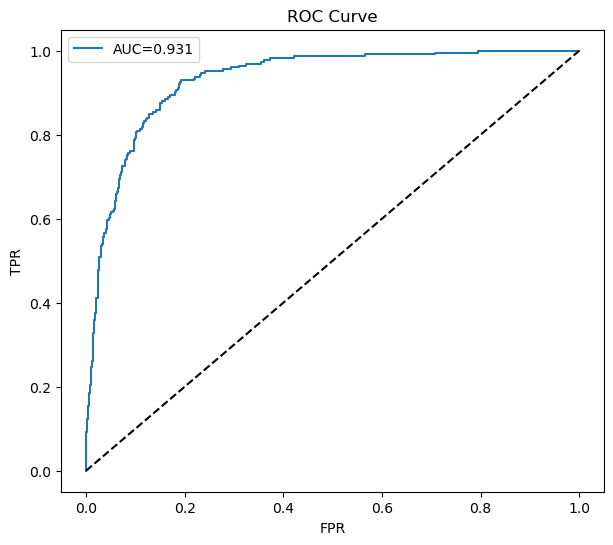

In [78]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues', alpha=0.8)
plt.xticks([0, 1], ['No Podium', 'Podium'])
plt.yticks([0, 1], ['No Podium', 'Podium'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha='center', va='center', fontweight='bold', color='black')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR'), plt.ylabel('TPR'), plt.title('ROC Curve')
plt.legend()
plt.show()

The neural network performed well on predicting F1 podium finishes, usually hitting around 75–80% test accuracy with an ROC-AUC near 0.80—far better than the roughly 15% chance of getting a podium at random. It picked up on important factors like starting position, qualifying results, recent driver performance, and how strong a team has been historically. The model generalised well thanks to early stopping and dropout, which helped avoid overfitting. While it handled top drivers and teams reliably, unpredictable events—like crashes or risky pit calls—still caused misses, showing how chaotic racing can be. Overall, the ANN proved to be a solid approach for turning race and career data into podium predictions.